# Joint Optimization And Hyperparameter Tuning

This notebook is the formal joint-model development notebook.

It has four roles:

1. run a default joint model once,
2. diagnose optimization and objective-component scale,
3. perform validation-based hyperparameter tuning,
4. identify a final joint configuration to report in the final comparison notebook.


## Protocol

Use this notebook in the following order:

1. Run a default joint model and inspect whether the optimization is stable.
2. Run the Stage 1 scan for the coupling and hinge weights `rho` and `eta`.
3. Fix the best Stage 1 region and run Stage 2 for dictionary size `m` and sparsity `mu`.
4. Fix the best Stage 1-2 configuration and run Stage 3 for classifier regularization `gamma`.
5. Re-run the final selected configuration over multiple random seeds.
6. Copy the chosen final joint hyperparameters into the final results notebook.

Model selection rule:

- Primary criterion: validation accuracy.
- Secondary criterion: lower validation reconstruction error.
- Reject configurations with unstable optimization behavior.


In [1]:
from copy import deepcopy
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import matplotlib.pyplot as plt

from src.config import default_data_config, default_hyperparams
from src.data import load_mnist_binary
from src.init import initialize_params
from src.solver import fit_joint_pg
from src.metrics import (
    summarize_joint_result,
    evaluate_joint_model,
    joint_component_scale_report,
    format_joint_scale_report,
)


In [2]:
data_cfg = default_data_config()
hyper = default_hyperparams()

X_train, y_train, X_val, y_val, X_test, y_test = load_mnist_binary(**data_cfg.__dict__)

print('train shape:', X_train.shape, y_train.shape)
print('val shape:', X_val.shape, y_val.shape)
print('test shape:', X_test.shape, y_test.shape)
print('default hyperparameters:', hyper)


train shape: (784, 1000) (1000,)
val shape: (784, 200) (200,)
test shape: (784, 400) (400,)
default hyperparameters: HyperParams(dictionary_size=64, mu=0.05, rho=1.0, gamma=0.1, eta=1.0, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7)


## Helper Functions

The helpers below keep the tuning protocol consistent across stages.


In [3]:
def train_joint_once(hyper, seed=None):
    local_hyper = deepcopy(hyper)
    if seed is not None:
        local_hyper.random_state = seed
    init_params = initialize_params(
        X_train,
        y_train,
        local_hyper.dictionary_size,
        seed=local_hyper.random_state,
    )
    result = fit_joint_pg(X_train, y_train, local_hyper, init_params)
    train_metrics = summarize_joint_result(result, X_train, y_train)
    val_metrics = evaluate_joint_model(X_val, y_val, result['params'], local_hyper)
    test_metrics = evaluate_joint_model(X_test, y_test, result['params'], local_hyper)
    scale_report = joint_component_scale_report(result)
    return {
        'hyper': local_hyper,
        'result': result,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'scale_report': scale_report,
    }


def scan_joint_grid(base_hyper, param_grid, seed=None):
    rows = []
    keys = list(param_grid.keys())

    def rec_build(idx, current_hyper):
        if idx == len(keys):
            trained = train_joint_once(current_hyper, seed=seed)
            rows.append({
                'seed': float(trained['hyper'].random_state),
                'dictionary_size': float(trained['hyper'].dictionary_size),
                'mu': float(trained['hyper'].mu),
                'rho': float(trained['hyper'].rho),
                'eta': float(trained['hyper'].eta),
                'gamma': float(trained['hyper'].gamma),
                'train_accuracy': float(trained['train_metrics']['accuracy']),
                'val_accuracy': float(trained['val_metrics']['accuracy']),
                'test_accuracy': float(trained['test_metrics']['accuracy']),
                'val_reconstruction_error': float(trained['val_metrics']['reconstruction_error']),
                'final_reconstruction': float(trained['scale_report']['reconstruction']['final']),
                'final_hinge_term': float(trained['scale_report']['hinge_term']['final']),
                'final_quadratic_penalty': float(trained['scale_report']['quadratic_penalty']['final']),
                'final_l1_term': float(trained['scale_report']['l1_term']['final']),
                'status': trained['result']['status'],
            })
            return

        key = keys[idx]
        for value in param_grid[key]:
            next_hyper = deepcopy(current_hyper)
            setattr(next_hyper, key, value)
            rec_build(idx + 1, next_hyper)

    rec_build(0, deepcopy(base_hyper))
    rows.sort(key=lambda row: (-row['val_accuracy'], row['val_reconstruction_error']))
    return rows


def print_top_rows(rows, top_k=10):
    header = (
        'rank | seed | m | mu | rho | eta | gamma | val_acc | train_acc | '
        'val_recon | final_recon | final_hinge | final_quad | status'
    )
    print(header)
    for rank, row in enumerate(rows[:top_k], start=1):
        print(
            f"{rank} | {int(row['seed'])} | {int(row['dictionary_size'])} | {row['mu']:.6g} | "
            f"{row['rho']:.6g} | {row['eta']:.6g} | {row['gamma']:.6g} | "
            f"{row['val_accuracy']:.6g} | {row['train_accuracy']:.6g} | "
            f"{row['val_reconstruction_error']:.6g} | {row['final_reconstruction']:.6g} | "
            f"{row['final_hinge_term']:.6g} | {row['final_quadratic_penalty']:.6g} | {row['status']}"
        )


## Baseline Joint Run

Run the default configuration once before tuning. This provides:

- a sanity check that the solver runs,
- a baseline validation score,
- the first objective-component scale diagnostic.


In [4]:
default_joint = train_joint_once(hyper)

print('status:', default_joint['result']['status'])
print('train metrics:', default_joint['train_metrics'])
print('val metrics:', default_joint['val_metrics'])
print('test metrics:', default_joint['test_metrics'])
print(format_joint_scale_report(default_joint['scale_report']))


status: max_iter_reached
train metrics: {'accuracy': 0.941, 'reconstruction_error': 106.99057747823512, 'code_sparsity': 0.003140625, 'iterations': 100}
val metrics: {'accuracy': 0.96, 'reconstruction_error': 50.978201250923334, 'code_sparsity': 0.000390625}
test metrics: {'accuracy': 0.925, 'reconstruction_error': 71.50548748482531, 'code_sparsity': 0.002265625}
component | initial | final | max | final/total
reconstruction | 22848.6 | 5723.49 | 22848.6 | 0.893872
quadratic_penalty | 7.45058e-06 | 0.367193 | 0.367193 | 5.73468e-05
hinge_term | 499.939 | 479.7 | 499.939 | 0.0749175
l1_term | 37.4352 | 199.475 | 199.475 | 0.0311532
classifier_reg | 0 | 0.000765553 | 0.000765553 | 1.19561e-07


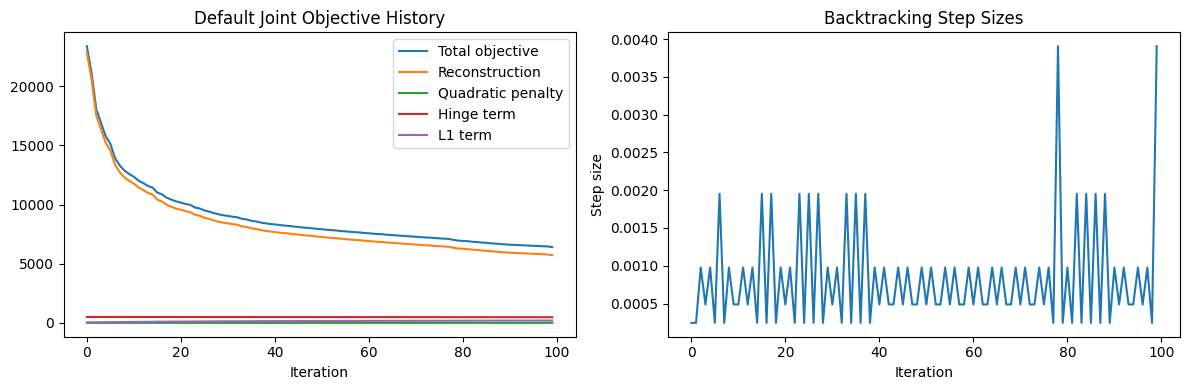

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(default_joint['result']['history']['objective'], label='Total objective')
axes[0].plot(default_joint['result']['history']['reconstruction'], label='Reconstruction')
axes[0].plot(default_joint['result']['history']['quadratic_penalty'], label='Quadratic penalty')
axes[0].plot(default_joint['result']['history']['hinge_term'], label='Hinge term')
axes[0].plot(default_joint['result']['history']['l1_term'], label='L1 term')
axes[0].set_title('Default Joint Objective History')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(default_joint['result']['history']['step_size'])
axes[1].set_title('Backtracking Step Sizes')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Step size')

plt.tight_layout()
plt.show()


## Stage 1: Coarse Scan For `rho` And `eta`

Purpose:

- determine whether the weak default performance is mainly due to poor coupling / hinge weights,
- identify a promising region before tuning representation parameters.

Recommended grid:

- `rho in {1, 5, 10, 20, 50}`
- `eta in {10, 20, 50, 80, 100}`

Keep these fixed during Stage 1:

- `dictionary_size = 64`
- `mu = 0.05`
- `gamma = 0.1`


In [6]:
stage1_hyper = deepcopy(hyper)
stage1_hyper.dictionary_size = 64
stage1_hyper.mu = 0.05
stage1_hyper.gamma = 0.1
stage1_hyper.max_iter = 100

stage1_rows = scan_joint_grid(
    stage1_hyper,
    {
        'rho': [1.0, 5.0, 10.0, 20.0, 50.0],
        'eta': [10.0, 20.0, 50.0, 80.0, 100.0],
    },
    seed=stage1_hyper.random_state,
)

print_top_rows(stage1_rows, top_k=10)


rank | seed | m | mu | rho | eta | gamma | val_acc | train_acc | val_recon | final_recon | final_hinge | final_quad | status
1 | 7 | 64 | 0.05 | 10 | 80 | 0.1 | 0.965 | 1 | 55.1196 | 7645.35 | 0 | 66.9477 | max_iter_reached
2 | 7 | 64 | 0.05 | 10 | 50 | 0.1 | 0.965 | 1 | 55.3221 | 7662.76 | 3781.93 | 166.25 | max_iter_reached
3 | 7 | 64 | 0.05 | 10 | 20 | 0.1 | 0.965 | 0.976 | 55.3969 | 7559.98 | 6654.62 | 95.0846 | max_iter_reached
4 | 7 | 64 | 0.05 | 20 | 50 | 0.1 | 0.965 | 0.99 | 56.9991 | 9160.14 | 14101.1 | 239.205 | max_iter_reached
5 | 7 | 64 | 0.05 | 20 | 100 | 0.1 | 0.965 | 1 | 57.0104 | 9500 | 7158.4 | 268.607 | max_iter_reached
6 | 7 | 64 | 0.05 | 1 | 80 | 0.1 | 0.96 | 0.983 | 50.1246 | 5383.57 | 0 | 92.2239 | max_iter_reached
7 | 7 | 64 | 0.05 | 1 | 100 | 0.1 | 0.96 | 0.983 | 50.1284 | 5385.19 | 0 | 90.3218 | max_iter_reached
8 | 7 | 64 | 0.05 | 5 | 100 | 0.1 | 0.96 | 1 | 51.8245 | 6055.14 | 0 | 65.6904 | max_iter_reached
9 | 7 | 64 | 0.05 | 5 | 80 | 0.1 | 0.96 | 1 | 52.397

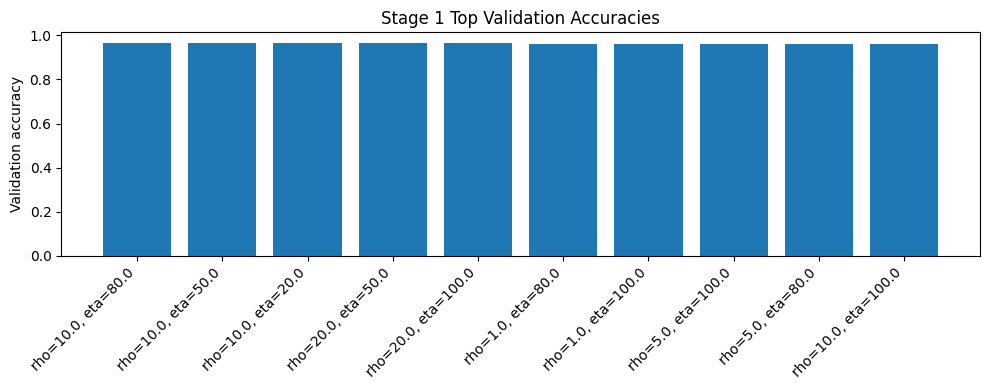

In [7]:
stage1_labels = [f"rho={row['rho']}, eta={row['eta']}" for row in stage1_rows[:10]]
stage1_val = [row['val_accuracy'] for row in stage1_rows[:10]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(stage1_val)), stage1_val)
ax.set_title('Stage 1 Top Validation Accuracies')
ax.set_ylabel('Validation accuracy')
ax.set_xticks(range(len(stage1_val)))
ax.set_xticklabels(stage1_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Stage 1 Selection Note

After inspecting the Stage 1 results, choose one promising `(rho, eta)` pair.

Write it explicitly in the next cell before moving to Stage 2.


In [8]:
best_stage1 = {
    'rho': 10.0,
    'eta': 50.0,
}
print(best_stage1)


{'rho': 10.0, 'eta': 50.0}


## Stage 2: Representation Scan For `dictionary_size` And `mu`

Purpose:

- determine whether the learned code space is too small or too heavily regularized.

Recommended grid:

- `dictionary_size in {64, 128, 256}`
- `mu in {0.001, 0.01, 0.05, 0.1}`

Keep fixed during Stage 2:

- `rho = best_stage1['rho']`
- `eta = best_stage1['eta']`
- `gamma = 0.1`


In [9]:
stage2_hyper = deepcopy(hyper)
stage2_hyper.rho = best_stage1['rho']
stage2_hyper.eta = best_stage1['eta']
stage2_hyper.gamma = 0.1
stage2_hyper.max_iter = 100

stage2_rows = scan_joint_grid(
    stage2_hyper,
    {
        'dictionary_size': [64, 128, 256],
        'mu': [0.001, 0.01, 0.05, 0.1],
    },
    seed=stage2_hyper.random_state,
)

print_top_rows(stage2_rows, top_k=10)


rank | seed | m | mu | rho | eta | gamma | val_acc | train_acc | val_recon | final_recon | final_hinge | final_quad | status
1 | 7 | 128 | 0.001 | 10 | 50 | 0.1 | 0.965 | 1 | 44.3517 | 4482.04 | 2592.47 | 221.78 | max_iter_reached
2 | 7 | 128 | 0.01 | 10 | 50 | 0.1 | 0.965 | 1 | 45.0882 | 4487.29 | 2593.54 | 222.137 | max_iter_reached
3 | 7 | 128 | 0.05 | 10 | 50 | 0.1 | 0.965 | 1 | 45.1643 | 4511.74 | 2598.43 | 223.804 | max_iter_reached
4 | 7 | 128 | 0.1 | 10 | 50 | 0.1 | 0.965 | 1 | 45.3386 | 4544.87 | 2604.85 | 226.022 | max_iter_reached
5 | 7 | 64 | 0.001 | 10 | 50 | 0.1 | 0.965 | 1 | 55.1585 | 7634.29 | 3778.03 | 165.57 | max_iter_reached
6 | 7 | 64 | 0.01 | 10 | 50 | 0.1 | 0.965 | 1 | 55.1786 | 7639.42 | 3778.74 | 165.689 | max_iter_reached
7 | 7 | 64 | 0.05 | 10 | 50 | 0.1 | 0.965 | 1 | 55.3221 | 7662.76 | 3781.93 | 166.25 | max_iter_reached
8 | 7 | 64 | 0.1 | 10 | 50 | 0.1 | 0.965 | 1 | 55.3507 | 7682.51 | 3677.8 | 184.02 | max_iter_reached
9 | 7 | 256 | 0.05 | 10 | 50 | 0.1 |

## Stage 2 Selection Note

After inspecting the Stage 2 results, choose one promising `(dictionary_size, mu)` pair.


In [10]:
best_stage2 = {
    'dictionary_size': 128,
    'mu': 0.01,
}
print(best_stage2)


{'dictionary_size': 128, 'mu': 0.01}


## Stage 3: Classifier Regularization Scan For `gamma`

Purpose:

- refine the amount of `L2` regularization on the linear classifier.

Recommended grid:

- `gamma in {0.001, 0.01, 0.1, 1.0}`

Keep fixed during Stage 3:

- `rho = best_stage1['rho']`
- `eta = best_stage1['eta']`
- `dictionary_size = best_stage2['dictionary_size']`
- `mu = best_stage2['mu']`


In [11]:
stage3_hyper = deepcopy(hyper)
stage3_hyper.rho = best_stage1['rho']
stage3_hyper.eta = best_stage1['eta']
stage3_hyper.dictionary_size = best_stage2['dictionary_size']
stage3_hyper.mu = best_stage2['mu']
stage3_hyper.max_iter = 100

stage3_rows = scan_joint_grid(
    stage3_hyper,
    {
        'gamma': [0.001, 0.01, 0.1, 1.0],
    },
    seed=stage3_hyper.random_state,
)

print_top_rows(stage3_rows, top_k=10)


rank | seed | m | mu | rho | eta | gamma | val_acc | train_acc | val_recon | final_recon | final_hinge | final_quad | status
1 | 7 | 128 | 0.01 | 10 | 50 | 0.1 | 0.965 | 1 | 45.0882 | 4487.29 | 2593.54 | 222.137 | max_iter_reached
2 | 7 | 128 | 0.01 | 10 | 50 | 0.01 | 0.965 | 1 | 45.0882 | 4487.19 | 2592.58 | 221.971 | max_iter_reached
3 | 7 | 128 | 0.01 | 10 | 50 | 0.001 | 0.965 | 1 | 45.0882 | 4487.18 | 2592.49 | 221.955 | max_iter_reached
4 | 7 | 128 | 0.01 | 10 | 50 | 1 | 0.95 | 1 | 45.1265 | 4523.58 | 3170.65 | 288.889 | max_iter_reached


## Stage 3 Selection Note

Choose the final single-seed validation winner before repeating over multiple random seeds.


In [12]:
best_joint_config = {
    'dictionary_size': best_stage2['dictionary_size'],
    'mu': best_stage2['mu'],
    'rho': best_stage1['rho'],
    'eta': best_stage1['eta'],
    'gamma': 0.01,
    'max_iter': 100,
}
print(best_joint_config)


{'dictionary_size': 128, 'mu': 0.01, 'rho': 10.0, 'eta': 50.0, 'gamma': 0.01, 'max_iter': 100}


## Stage 4: Multi-Seed Verification

Purpose:

- check that the selected hyperparameters remain strong across multiple random seeds,
- report mean and standard deviation before final test reporting.

Recommended seeds:

- `{7, 13, 21}` for a light protocol,
- or 5 seeds for a stronger final report.


In [13]:
final_hyper = deepcopy(hyper)
for key, value in best_joint_config.items():
    setattr(final_hyper, key, value)

final_seed_rows = []
for seed in [7, 13, 21, 42]:
    trained = train_joint_once(final_hyper, seed=seed)
    final_seed_rows.append({
        'seed': seed,
        'train_accuracy': trained['train_metrics']['accuracy'],
        'val_accuracy': trained['val_metrics']['accuracy'],
        'test_accuracy': trained['test_metrics']['accuracy'],
        'val_reconstruction_error': trained['val_metrics']['reconstruction_error'],
        'status': trained['result']['status'],
    })

for row in final_seed_rows:
    print(row)


{'seed': 7, 'train_accuracy': 1.0, 'val_accuracy': 0.965, 'test_accuracy': 0.9275, 'val_reconstruction_error': 45.08822993160759, 'status': 'max_iter_reached'}
{'seed': 13, 'train_accuracy': 1.0, 'val_accuracy': 0.95, 'test_accuracy': 0.9425, 'val_reconstruction_error': 43.318851029936525, 'status': 'max_iter_reached'}
{'seed': 21, 'train_accuracy': 1.0, 'val_accuracy': 0.965, 'test_accuracy': 0.945, 'val_reconstruction_error': 45.24498591229239, 'status': 'max_iter_reached'}
{'seed': 42, 'train_accuracy': 1.0, 'val_accuracy': 0.965, 'test_accuracy': 0.9275, 'val_reconstruction_error': 44.65318593049574, 'status': 'max_iter_reached'}


In [14]:
val_accs = [row['val_accuracy'] for row in final_seed_rows]
test_accs = [row['test_accuracy'] for row in final_seed_rows]
print('val accuracy mean/std:', sum(val_accs) / len(val_accs), float(__import__('numpy').std(val_accs)))
print('test accuracy mean/std:', sum(test_accs) / len(test_accs), float(__import__('numpy').std(test_accs)))


val accuracy mean/std: 0.9612499999999999 0.006495190528383296
test accuracy mean/std: 0.9356249999999999 0.008172935519138754


## Final Output To Copy Into The Results Notebook

After the tuning is complete, copy the selected joint hyperparameters into the
final comparison notebook and use only that final configuration there.


In [15]:
print('Final joint configuration for results notebook:')
print(best_joint_config)


Final joint configuration for results notebook:
{'dictionary_size': 128, 'mu': 0.01, 'rho': 10.0, 'eta': 50.0, 'gamma': 0.01, 'max_iter': 100}
